# Linear Regression — Full Deep Dive

In [3]:
# What is Linear Regression?
#     Find the BEST STRAIGHT LINE through data
#     that predicts a continuous value!

In [4]:
# Chapter 1 — The Problem
#     Imagine you're a teacher 👩‍🏫
#     You have data of 10 students:

#     Student 1 → studied 2 hours → got 50 marks
#     Student 2 → studied 4 hours → got 65 marks
#     Student 3 → studied 6 hours → got 75 marks
#     Student 4 → studied 8 hours → got 90 marks
#     Student 5 → studied 10 hours → got 95 marks

#     A NEW student comes → studied 7 hours
#     Question → how many marks will they get? 🤔


# This is exactly what Linear Regression solves!

In [6]:
# # Chapter 2 — The Graph

#     Plot the data on a graph:

# Marks
# 100|          ⭐ (10hrs, 95)
#  90|       ⭐ (8hrs, 90)
#  80|
#  70|    ⭐ (6hrs, 75)
#  60|  ⭐ (4hrs, 65)
#  50|⭐ (2hrs, 50)
#    |____________________
#    2  4  6  8  10   Study Hours

# See a pattern? More hours = more marks!
# The points form almost a straight line!




In [7]:
# Chapter 3 — The Line
#     Linear Regression draws the BEST line:

#     Marks
#     100|        ___⭐ (10hrs, 95)
#     90|     __/⭐ (8hrs, 90)
#     80|   _/
#     70|__/⭐ (6hrs, 75)
#     60|/⭐ (4hrs, 65)
#     50⭐ (2hrs, 50)
#     |____________________
#     2  4  6  8  10   Study Hours

# 7 hours → find on line → ~83 marks! ✅


# That's it! Linear Regression = finding best line!

In [ ]:
# The Math Behind It — Super Simple!

                # Equation of a line:
                # y = mx + c

                # y = output (marks)
                # x = input  (study hours)
                # m = slope  (how steep the line is)
                # c = intercept (where line crosses y axis)

# In ML terms:

        # y = w1x1 + w2x2 + ... + b

        # y  = prediction
        # x  = input features
        # w  = weights (slope) → model LEARNS these
        # b  = bias (intercept) → model LEARNS this too

In [ ]:
# What model actually does:

# Step 1 → starts with random w and b
# Step 2 → makes predictions
# Step 3 → checks how wrong it is (loss/error)
# Step 4 → adjusts w and b to reduce error
# Step 5 → repeats thousands of times
# Step 6 → finds BEST w and b! ✅

In [ ]:
# Chapter 4 — The Formula

#     Line formula is simple:

#     marks = m × study_hours + c

#     m = slope  → how steep is the line?
#                 "for every 1 hour, marks increase by m"

#     c = intercept → where does line start?
#                     "marks with 0 study hours"
#     Example:
#     marks = 5 × study_hours + 35

#     Student studies 7 hours:
#     marks = 5 × 7 + 35
#     marks = 35 + 35
#     marks = 70 ✅
#     m=5 means → every extra hour = 5 more marks!

In [ ]:
# Chapter 5 — How Model Learns

# Step 1 → model starts with random line (bad guess)
# Step 2 → checks how wrong it is
# Step 3 → adjusts line to be less wrong
# Step 4 → repeats 1000s of times
# Step 5 → finally finds BEST line! ✅

# Like a student improving after each mistake!

In [ ]:
# Cost Function — How model measures error
                    # Most common → Mean Squared Error (MSE):
                    # MSE = average of (actual - predicted)²

                    # Example:
                    # Actual marks    = [90, 75, 60]
                    # Predicted marks = [85, 80, 65]

                    # Errors     = [90-85, 75-80, 60-65]
                    #            = [5,    -5,    -5]

                    # Squared    = [25,   25,    25]

                    # MSE        = (25+25+25) / 3
                    #            = 25

In [ ]:
# Chapter 6 — How Wrong is Wrong? (MSE)

#         After drawing line, check predictions:

#         Student 1 → actual=50,  predicted=48  → error=2
#         Student 2 → actual=65,  predicted=67  → error=-2
#         Student 3 → actual=75,  predicted=74  → error=1

#         MSE = average of errors²
#             = (2² + 2² + 1²) / 3
#             = (4 + 4 + 1) / 3
#             = 3

#         Lower MSE = better line = better model!

# Why square?
# error = +2 and -2
#             +2 + -2 = 0 → looks perfect but it's not! ❌

#             +2² + -2² = 4 + 4 = 8 → honest error! ✅

In [ ]:
# Chapter 7 — Is Model Good? (R2 Score)
            # R2 score tells you:
            # "how much of the pattern did model capture?"

            # R2 = 0.95 → model captured 95% of pattern ✅ great!
            # R2 = 0.60 → model captured 60% of pattern 😐 okay
            # R2 = 0.20 → model captured 20% of pattern ❌ bad!

            # Simple rule:
            # Above 0.8 → good model ✅
            # Below 0.6 → bad model ❌

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error



# our data
data = {
    "study_hours": [2, 4, 6, 8, 10, 3, 7, 5, 9, 1],
    "marks"      : [50,65,75,90,95,55,85,70,92,40]
}

df= pd.DataFrame(data)
# X= Input(study hr) , y= Output(marks)
X= df[["study_hours"]]
y=df["marks"]
# split 80% train, 20% test

X_train, X_test, y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

# create and  train model
# training = findinf best line

model = LinearRegression()
model.fit(X_train,y_train) 

# see what model learned

print("slope (m) :", model.coef_)
print("intercept (C) :", model.intercept_)


    # predict on test data 

    y_pred= model.predict(X_test)

    # how good is model ?

    print("R2 score : ", r2_score(y_test,y_pred))


    # predict for new student
    new_student =[[7]]  # 7 study hr 
    print("Pridicted marks: ", model.predict(new_student))




slope (m) : [6.37037037]
intercept (C) : 36.55555555555555
R2 score :  0.966126061030293
Pridicted marks:  [81.14814815]


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
print ("slope :",round(model.coef_[0],2))
print("intercept (C) :", round(model.intercept_,2))
print("R2 score : ", round(r2_score(y_test,y_pred),2))
print("MSE       :", round(mean_squared_error(y_test, y_pred), 2))


slope : 6.37
intercept (C) : 36.56
R2 score :  0.97
MSE       : 6.17


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


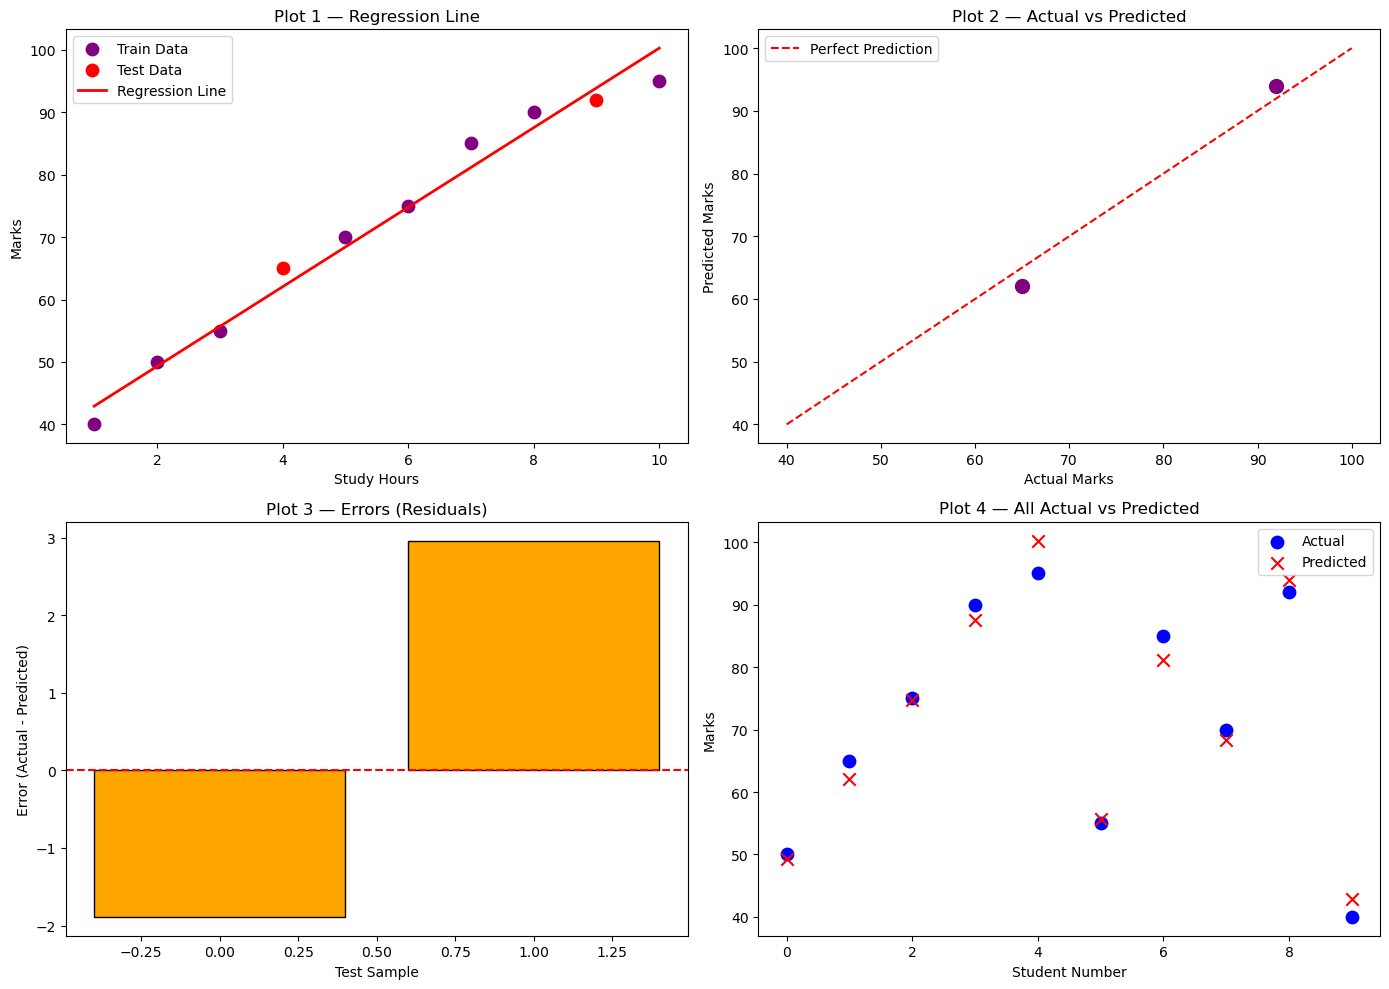

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# ── Plot 1 — Scatter + Regression Line ────────────

plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.scatter(X_train,y_train,color="Purple", label="Train Data",s=80)
plt.scatter(X_test,y_test,color="red", label="Test Data",s=80)
x_line = np.linspace(1,10,100).reshape(-1,1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Plot 1 — Regression Line")
plt.legend()

# ── Plot 2 — Actual vs Predicted ──────────────────
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred, color="purple", s=100)
plt.plot([40, 100], [40, 100], color="red",
         linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Plot 2 — Actual vs Predicted")
plt.legend()

# ── Plot 3 — Residuals (Errors) ───────────────────
plt.subplot(2, 2, 3)
residuals = y_test - y_pred
plt.bar(range(len(residuals)), residuals, color="orange", edgecolor="black")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Test Sample")
plt.ylabel("Error (Actual - Predicted)")
plt.title("Plot 3 — Errors (Residuals)")

# ── Plot 4 — All Predictions vs Actual ───────────
plt.subplot(2, 2, 4)
y_all_pred = model.predict(X)
plt.scatter(range(len(y)), y,        color="blue",
            label="Actual",    s=80)
plt.scatter(range(len(y)), y_all_pred, color="red",
            label="Predicted", s=80, marker="x")
plt.xlabel("Student Number")
plt.ylabel("Marks")
plt.title("Plot 4 — All Actual vs Predicted")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# **What each plot tells you:**
# ```
# Plot 1 → Regression Line
#          blue  = training data
#          green = testing data
#          red   = line model learned
         
# Plot 2 → Actual vs Predicted
#          closer to red line = better model!
#          perfect model = all points ON red line

# Plot 3 → Errors (Residuals)
#          bar above 0 = model predicted too low
#          bar below 0 = model predicted too high
#          perfect model = all bars at 0

# Plot 4 → All predictions vs actual
#          blue dots  = real marks
#          red crosses = what model predicted
#          closer together = better model!

In [16]:
# Notes Summary 📝

# Linear Regression:
# → used for predicting NUMBERS
# → draws best straight line through data
# → formula: y = mx + c
# → m (slope)     = model.coef_
# → c (intercept) = model.intercept_

# Evaluation:
# → MSE   = average squared error (lower = better)
# → RMSE  = √MSE (same unit as target)
# → R2    = how much pattern captured (closer to 1 = better)

# Code steps:
# 1. define X and y
# 2. train_test_split
# 3. LinearRegression()
# 4. model.fit(X_train, y_train)
# 5. model.predict(X_test)
# 6. r2_score(y_test, y_pred)

In [ ]:
# # If model.coef_ = 6, what does that mean in simple words?

#     marks = m × study_hours + c

#     model.coef_ is just m (slope)
#     So if coef_ = 6:
#     marks = 6 × study_hours + c

#                 Student studies 1 hour → 6 marks
#                 Student studies 2 hours → 12 marks
#                 Student studies 3 hours → 18 marks

#                 Every 1 extra hour = 6 more marks!

#     Simple rule:

#     coef_ = 6 means:
#     "for every 1 unit increase in input
#     output increases by 6"

#     coef_ = 6  → 1 hour more study = 6 more marks
#     coef_ = 10 → 1 hour more study = 10 more marks
#     coef_ = 2  → 1 hour more study = 2 more marks


In [ ]:
# model.coef_  = slope
#              = how much output changes
#                for every 1 unit change in input

# model.intercept_ = starting point
#                  = output when input is zero